# We need to check the dataset firstly

## Loading the financial dataset 

In [445]:
import pandas as pd

file_path = "/Users/apurvpanbude/financial_risk_project/financial_risk_project/data/raw/s&p500 financials_csv.csv"
financial_df = pd.read_csv(file_path)

print(financial_df.head())
print(financial_df.dtypes)


  Symbol                 Name                  Sector   Price  Price/Earnings  \
0    MMM           3M Company             Industrials  222.89           24.31   
1    AOS      A.O. Smith Corp             Industrials   60.24           27.76   
2    ABT  Abbott Laboratories             Health Care   56.27           22.51   
3   ABBV          AbbVie Inc.             Health Care  108.48           19.41   
4    ACN        Accenture plc  Information Technology  150.51           25.47   

   Dividend Yield  Earnings/Share  52 Week Low  52 Week High    Market Cap  \
0        2.332862            7.92       259.77       175.490  138721055226   
1        1.147959            1.70        68.39        48.925   10783419933   
2        1.908982            0.26        64.60        42.280  102121042306   
3        2.499560            3.29       125.86        60.050  181386347059   
4        1.714470            5.44       162.60       114.820   98765855553   

         EBITDA  Price/Sales  Price/Book  \


## Loading the ESG Dataset 

In [447]:
file_path ="/Users/apurvpanbude/financial_risk_project/data/processed/SP500ESGRisk_cleaned.csv"
df_esg = pd.read_csv(file_path)
print(df_esg.head())
print(df_esg.dtypes)

  Symbol                      Name  \
0   ENPH      Enphase Energy, Inc.   
1    EMN  Eastman Chemical Company   
2    DPZ       Domino's Pizza Inc.   
3    DAY            Dayforce, Inc.   
4    DVA               Davita Inc.   

                                             Address             Sector  \
0  47281 Bayside Parkway\nFremont, CA 94538\nUnit...         Technology   
1  200 South Wilcox Drive\nKingsport, TN 37662\nU...    Basic Materials   
2  30 Frank Lloyd Wright Drive\nAnn Arbor, MI 481...  Consumer Cyclical   
3  3311 East Old Shakopee Road\nMinneapolis, MN 5...         Technology   
4  2000 16th Street\nDenver, CO 80202\nUnited States         Healthcare   

                  Industry Full Time Employees  \
0                    Solar               3,157   
1      Specialty Chemicals              14,000   
2              Restaurants               6,500   
3   Software - Application               9,084   
4  Medical Care Facilities              70,000   

                   

## check the Null values in both the Dataset 

In [354]:
print(df_esg.isnull().sum())
print (financial_df.isnull().sum())

Symbol                     0
Name                       0
Address                    0
Sector                     0
Industry                   0
Full Time Employees        4
Description                0
Total ESG Risk score       0
Environment Risk Score     0
Governance Risk Score      0
Social Risk Score          0
Controversy Level          0
Controversy Score          0
ESG Risk Percentile       72
ESG Risk Level             0
dtype: int64
Symbol            0
Name              0
Sector            0
Price             0
Price/Earnings    2
Dividend Yield    0
Earnings/Share    0
52 Week Low       0
52 Week High      0
Market Cap        0
EBITDA            0
Price/Sales       0
Price/Book        8
SEC Filings       0
dtype: int64


In [355]:
print(df_esg.describe())
print(financial_df.describe())

       Total ESG Risk score  Environment Risk Score  Governance Risk Score  \
count            502.000000              502.000000             502.000000   
mean              21.533721                5.739767               6.725116   
std                6.374954                4.712312               2.043269   
min                7.100000                0.000000               3.000000   
25%               16.900000                2.000000               5.400000   
50%               21.533721                5.150000               6.600000   
75%               25.175000                8.000000               7.400000   
max               41.700000               25.000000              19.400000   

       Social Risk Score  Controversy Score  
count         502.000000         502.000000  
mean            9.070465           2.007444  
std             3.384889           0.710595  
min             0.800000           1.000000  
25%             7.200000           2.000000  
50%             9.070

In [356]:
print(df_esg.isnull().sum()[df_esg.isnull().sum() > 0])

Full Time Employees     4
ESG Risk Percentile    72
dtype: int64


In [357]:
print(df_esg.head())

  Symbol                      Name  \
0   ENPH      Enphase Energy, Inc.   
1    EMN  Eastman Chemical Company   
2    DPZ       Domino's Pizza Inc.   
3    DAY            Dayforce, Inc.   
4    DVA               Davita Inc.   

                                             Address             Sector  \
0  47281 Bayside Parkway\nFremont, CA 94538\nUnit...         Technology   
1  200 South Wilcox Drive\nKingsport, TN 37662\nU...    Basic Materials   
2  30 Frank Lloyd Wright Drive\nAnn Arbor, MI 481...  Consumer Cyclical   
3  3311 East Old Shakopee Road\nMinneapolis, MN 5...         Technology   
4  2000 16th Street\nDenver, CO 80202\nUnited States         Healthcare   

                  Industry Full Time Employees  \
0                    Solar               3,157   
1      Specialty Chemicals              14,000   
2              Restaurants               6,500   
3   Software - Application               9,084   
4  Medical Care Facilities              70,000   

                   

## Changed the datatype from object to int for better handling 

In [359]:
print(df_esg['Full Time Employees'].dtype)  

object


In [360]:
df_esg['Full Time Employees'] = df_esg['Full Time Employees'].str.replace(',', '', regex=True)
## removed the ',' using the above code 
df_esg['Full Time Employees'] = df_esg['Full Time Employees'].astype('Int64')

## Using imputation median for the missing values in the Full time employees column 

In [362]:
df_esg['Full Time Employees'].fillna(df_esg['Full Time Employees'].median(), inplace=True)


/var/folders/yp/fhmczvyn2sx778505bnnqmgr0000gn/T/ipykernel_94882/2435460094.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_esg['Full Time Employees'].fillna(df_esg['Full Time Employees'].median(), inplace=True)


## Handled the missing values from the Full time employees columns using imputation and checked 

In [364]:
print(df_esg.isnull().sum())
print (financial_df.isnull().sum())

Symbol                     0
Name                       0
Address                    0
Sector                     0
Industry                   0
Full Time Employees        0
Description                0
Total ESG Risk score       0
Environment Risk Score     0
Governance Risk Score      0
Social Risk Score          0
Controversy Level          0
Controversy Score          0
ESG Risk Percentile       72
ESG Risk Level             0
dtype: int64
Symbol            0
Name              0
Sector            0
Price             0
Price/Earnings    2
Dividend Yield    0
Earnings/Share    0
52 Week Low       0
52 Week High      0
Market Cap        0
EBITDA            0
Price/Sales       0
Price/Book        8
SEC Filings       0
dtype: int64


## handling the missing values of ESG percentile by calculating them using Total ESG scores 

In [366]:
import pandas as pd 
import numpy as np 
missing_percentile = df_esg['ESG Risk Percentile'].isnull().sum()
print (missing_percentile)
print(df_esg['ESG Risk Percentile'].dtype) 

72
object


In [367]:
df_esg['ESG Risk Percentile']= df_esg['ESG Risk Percentile'].fillna(0)
print (df_esg['ESG Risk Percentile'])
print (df_esg['Total ESG Risk score'])

0                    0
1      50th percentile
2      66th percentile
3                    0
4      38th percentile
            ...       
497     3rd percentile
498    69th percentile
499    48th percentile
500    51st percentile
501    89th percentile
Name: ESG Risk Percentile, Length: 502, dtype: object
0      21.533721
1      25.300000
2      29.200000
3      21.533721
4      22.600000
         ...    
497     9.800000
498    29.900000
499    24.800000
500    25.400000
501    37.300000
Name: Total ESG Risk score, Length: 502, dtype: float64


# Calculating the ESG Risk percentile Using ESG risk scores 

In [369]:
import numpy as np
df_esg.loc[np.isclose(df_esg['ESG Risk Percentile'], 0.526892), 'ESG Risk Percentile'] = 00

print (df_esg)

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

In [ ]:
from scipy.stats import rankdata


ranked_scores = rankdata(df_esg['Total ESG Risk score'], method='average')
df_esg['Calculated_ESG_Percentile'] = ranked_scores / len(df_esg)*100

print(df_esg)

In [ ]:
df_esg['ESG Risk Percentile'] = df_esg.apply(
    lambda row: row['Calculated_ESG_Percentile'] if row['ESG Risk Percentile'] == 0 else row['ESG Risk Percentile'], axis=1
)
print (df_esg)

# Handled the missing values from the ESG risk Percentile using  Total ESG risk Scores also checked below

In [ ]:
print(df_esg.isnull().sum())
print (df_esg) 

# Now handling the financial_df values which are null

In [ ]:
print (financial_df.isnull().sum()) 
print (financial_df)

# Checking how many values missing like how much percentage are missing 

In [ ]:
print(financial_df['Price/Earnings'].isnull().sum())  
print(financial_df['Price/Earnings'].isnull().mean() * 100)  

# Applying median for the missing values in the Price/earning columns

In [ ]:
financial_df['Price/Earnings'].fillna(financial_df['Price/Earnings'].median(), inplace=True)
print (financial_df)

In [ ]:
print(financial_df['Price/Earnings'].isnull().sum())  

# Handling the missing values from price/book 

In [ ]:
print(financial_df['Price/Book'].isnull().sum())  
print(financial_df['Price/Book'].isnull().mean() * 100)  

# Checking the outliers in this price/book columns 

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(x=financial_df['Price/Book'])
plt.title("Boxplot of Price/Book (Visualizes Outliers)")
plt.show()

# Histogram
plt.figure(figsize=(10, 6))
sns.histplot(financial_df['Price/Book'], kde=True)
plt.title("Distribution of Price/Book")
plt.show()

In [ ]:
print (financial_df["Price/Book"])

In [ ]:
print (financial_df.isnull().sum)

# Correaltion Matrix for Financial Dataframe to clean the Price/book 


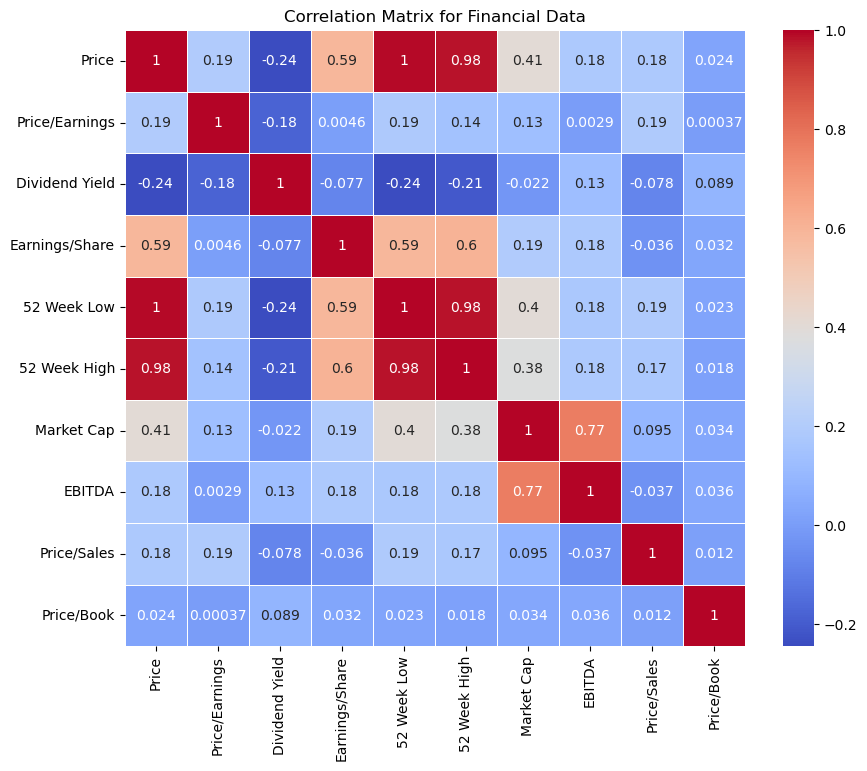

In [433]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = financial_df.corr(numeric_only=True)  
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix for Financial Data')
plt.show()


# Predcited the Price/Book values using Price as the main feature 

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Create a copy to avoid modifying original data
df = financial_df.copy()

#  Extract rows where Price/Book is NOT null (for training)
train_data = df[df['Price/Book'].notnull()][['Price', 'Price/Book']].dropna()

#  Extract rows where Price/Book is null and Price is not null (for prediction)
missing_data = df[df['Price/Book'].isnull() & df['Price'].notnull()][['Price']]

#  Train regression model
reg = LinearRegression()
reg.fit(train_data[['Price']], train_data['Price/Book'])


predicted_values = reg.predict(missing_data[['Price']])


df.loc[df['Price/Book'].isnull() & df['Price'].notnull(), 'Price/Book'] = predicted_values




In [ ]:
print (predicted_values)

In [ ]:
financial_df[['Price/Sales', 'Price', '52 Week Low']].corr()


# Predicted the missing  values using all the three features that were having the most correaltion with the missing value feature which was Price/book

In [ ]:
df = financial_df.copy()
# Features to use
features = ['Price/Sales', 'Price', '52 Week Low']  

# Filter rows where 'Price/Book' is not null for training
train_data = df[df['Price/Book'].notnull()]
X_train = train_data[features]
y_train = train_data['Price/Book']

# Rows where 'Price/Book' is missing but features are available
missing_data = df[df['Price/Book'].isnull()]
X_missing = missing_data[features]

# Drop rows where any of the features used for prediction are missing
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]
X_missing = X_missing.dropna()

# Train and predict
reg = LinearRegression()
reg.fit(X_train, y_train)
predicted_values = reg.predict(X_missing)

# Impute the missing values
df.loc[X_missing.index, 'Price/Book'] = predicted_values

In [ ]:
print (predicted_values)

In [ ]:
print(financial_df).isnull().sum()

# Merging both the datasets financial_df and df_esg in one merged_df dataset 

In [ ]:
# Left join: keep all companies from financial_df
merged_df = financial_df.merge(df_esg, on='Symbol', how='left')

# Check again
print(merged_df.shape)
merged_df.head()


In [ ]:
print(merged_df.describe)

In [ ]:
print(merged_df.columns.tolist())


In [ ]:
print(merged_df.isnull().sum()) 

In [ ]:
# Find the rows where 'Price/Book' is missing
missing_indices = financial_df['Price/Book'][financial_df['Price/Book'].isnull()].index

# Insert the predicted values at the missing positions
financial_df.loc[missing_indices, 'Price/Book'] = predicted_values




In [ ]:
# Check if any missing values are left
print(financial_df['Price/Book'].isnull().sum())

# Checked if the datasets have merged Correctly

In [ ]:
# 1. How many companies in each dataset?
print("Financial dataset:", financial_df['Symbol'].nunique())
print("ESG dataset:", df_esg['Symbol'].nunique())

# 2. After merging:
print("Merged dataset shape:", merged_df.shape)
print("Unique Symbols in merged dataset:", merged_df['Symbol'].nunique())


In [ ]:
esg_columns = [
    'Total ESG Risk score', 'Environment Risk Score', 'Governance Risk Score',
    'Social Risk Score', 'Controversy Level', 'Controversy Score',
    'ESG Risk Percentile', 'ESG Risk Level', 'Calculated_ESG_Percentile'
]

print(merged_df[esg_columns].isnull().sum())


# predicting the ESG values wiht the help of the financial dataset 

In [435]:
print(merged_df.dtypes)


Symbol                        object
Name_x                        object
Sector_x                      object
Price                        float64
Dividend Yield               float64
Earnings/Share               float64
52 Week Low                  float64
52 Week High                 float64
Market Cap                     int64
EBITDA                       float64
Price/Sales                  float64
Price/Book                   float64
SEC Filings                   object
Total ESG Risk score         float64
Environment Risk Score       float64
Governance Risk Score        float64
Social Risk Score            float64
Controversy Level              int64
Controversy Score            float64
ESG Risk Percentile           object
ESG Risk Level                 int64
Calculated_ESG_Percentile    float64
EBITDA_log                   float64
Market_Cap_log               float64
Composite_Risk_Score         float64
Risk_Category                 object
Predicted_Risk                object
d

# Used label Encoder to handel the categorical data type as only the numeric data can be using in the classifier 

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Assuming 'Controversy Level' is a categorical column
label_encoder = LabelEncoder()

# Apply label encoding to 'Controversy Level' column
merged_df['Controversy Level'] = label_encoder.fit_transform(merged_df['Controversy Level'])

# Check the result
print(merged_df['Controversy Level'].head())


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
label_encoder = LabelEncoder()

# Apply label encoding to the 'ESG Risk Score' column
merged_df['ESG Risk Level'] = label_encoder.fit_transform(merged_df['ESG Risk Level'])

# Check the result
print(merged_df['ESG Risk Level'].head())


In [ ]:
# Check unique values in each ESG column
for col in esg_columns:
    print(f"Unique values in {col}: {merged_df[col].unique()}")


# using Standardization on the merged dataset 


In [ ]:
from sklearn.preprocessing import StandardScaler

# Assuming merged_df is the merged dataset
scaler = StandardScaler()

# Apply standardization to the numeric columns in merged_df
merged_df_standardized = pd.DataFrame(scaler.fit_transform(merged_df.select_dtypes(include=['float64', 'int64'])), 
                                      columns=merged_df.select_dtypes(include=['float64', 'int64']).columns)

# Optionally, if you want to merge back with non-numeric columns:
merged_df_standardized = pd.concat([merged_df.select_dtypes(exclude=['float64', 'int64']), merged_df_standardized], axis=1)


In [ ]:
# After standardization (merged_df_standardized)
print("\nAfter standardization (merged_df_standardized):")
print(merged_df_standardized.select_dtypes(include=['float64', 'int64']).describe())

# Train a model to precidt the missing values spiltting the dataset in Training and testing 

In [ ]:
# Columns to predict (target columns)
esg_columns = [
    'Total ESG Risk score', 'Environment Risk Score', 'Governance Risk Score',
    'Social Risk Score', 'Controversy Level', 'Controversy Score',
    'ESG Risk Percentile', 'ESG Risk Level', 'Calculated_ESG_Percentile'
]

# Rows where ESG values are NOT missing (Training data)
train_data = merged_df.dropna(subset=esg_columns)

# Rows where ESG values are missing (Prediction data)
predict_data = merged_df[merged_df[esg_columns[0]].isnull()]

print(train_data.shape)
print(predict_data.shape)

In [ ]:
# Financial features used for prediction (X)
financial_features = [
    'Price', 'Price/Earnings', 'Dividend Yield', 'Earnings/Share', 
    '52 Week Low', '52 Week High', 'Market Cap', 'EBITDA', 
    'Price/Sales', 'Price/Book'
]

# used Random forest for predicting values 

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Input features (X) and Target ESG scores (y)
X_train = train_data[financial_features]
y_train = train_data[esg_columns]

X_predict = predict_data[financial_features]


In [ ]:
# Create empty dataframe for storing predicted ESG scores
predicted_esg = pd.DataFrame(index=predict_data.index)

# Train one model for each ESG target
for col in esg_columns:
    model = RandomForestRegressor(random_state=42)
    model.fit(X_train, y_train[col])
    predicted_esg[col] = model.predict(X_predict)


# Replaced the predected values with the the missing values 

In [ ]:
for col in esg_columns:
    merged_df.loc[merged_df[col].isnull(), col] = predicted_esg[col]


In [ ]:
print(merged_df.isnull().sum())


In [ ]:
# Identify non-numeric columns
non_numeric_columns = merged_df.select_dtypes(exclude=['number']).columns
print("Non-numeric columns:", non_numeric_columns)


# Now the dataset is ready to get analysed and also can be used to predict the required outputs the dataset name is merged_df 

In [ ]:
merged_df.info(), merged_df.describe(),merged_df.shape, merged_df.columns
 

# Dropped the columns that werent needed and also had some missing values these columns arent needed in the model creation or the analysis 

In [ ]:

merged_df.drop(['Name_y', 'Address', 'Sector_y','Industry','Full Time Employees','Description'], axis=1, inplace=True)


In [ ]:
merged_df.drop(['Price/Earnings'], axis=1, inplace=True)

In [413]:
merged_df.info(), merged_df.describe(),merged_df.shape, merged_df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 27 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Symbol                     505 non-null    object 
 1   Name_x                     505 non-null    object 
 2   Sector_x                   505 non-null    object 
 3   Price                      505 non-null    float64
 4   Dividend Yield             505 non-null    float64
 5   Earnings/Share             505 non-null    float64
 6   52 Week Low                505 non-null    float64
 7   52 Week High               505 non-null    float64
 8   Market Cap                 505 non-null    int64  
 9   EBITDA                     505 non-null    float64
 10  Price/Sales                505 non-null    float64
 11  Price/Book                 497 non-null    float64
 12  SEC Filings                505 non-null    object 
 13  Total ESG Risk score       378 non-null    float64

(None,
              Price  Dividend Yield  Earnings/Share  52 Week Low  52 Week High  \
 count   505.000000      505.000000      505.000000   505.000000    505.000000   
 mean    103.830634        1.895953        3.753743   122.623832     83.536616   
 std     134.427636        1.537214        5.689036   155.362140    105.725473   
 min       2.820000        0.000000      -28.010000     6.590000      2.800000   
 25%      46.250000        0.794834        1.490000    56.250000     38.430000   
 50%      73.920000        1.769255        2.890000    86.680000     62.850000   
 75%     116.540000        2.781114        5.140000   140.130000     96.660000   
 max    1806.060000       12.661196       44.090000  2067.990000   1589.000000   
 
          Market Cap        EBITDA  Price/Sales   Price/Book  \
 count  5.050000e+02  5.050000e+02   505.000000   497.000000   
 mean   4.923944e+10  3.590328e+09     3.941705    14.453179   
 std    9.005017e+10  6.840544e+09     3.460110    89.660508 

# Doing EDA for the above features and doing features selection for the model and picking the only features that have a good impact on the output 


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 
merged_df.select_dtypes(include='number').hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()



In [ ]:
sns.histplot(merged_df['Earnings/Share'], bins=30, kde=True)
plt.title('Earnings Distribution')
plt.show()

sns.histplot(merged_df['EBITDA'], bins=30, kde=True)
plt.title('EBITDA Distribution')
plt.show()

sns.histplot(merged_df['Market Cap'], bins=30, kde=True)
plt.title('Market Cap Distribution')
plt.show()

In [ ]:
import numpy as np
merged_df['EBITDA_log'] = np.log1p(merged_df['EBITDA'])
merged_df['Market_Cap_log'] = np.log1p(merged_df['Market Cap'])

In [ ]:
merged_df.info(), merged_df.describe(),merged_df.shape, merged_df.columns

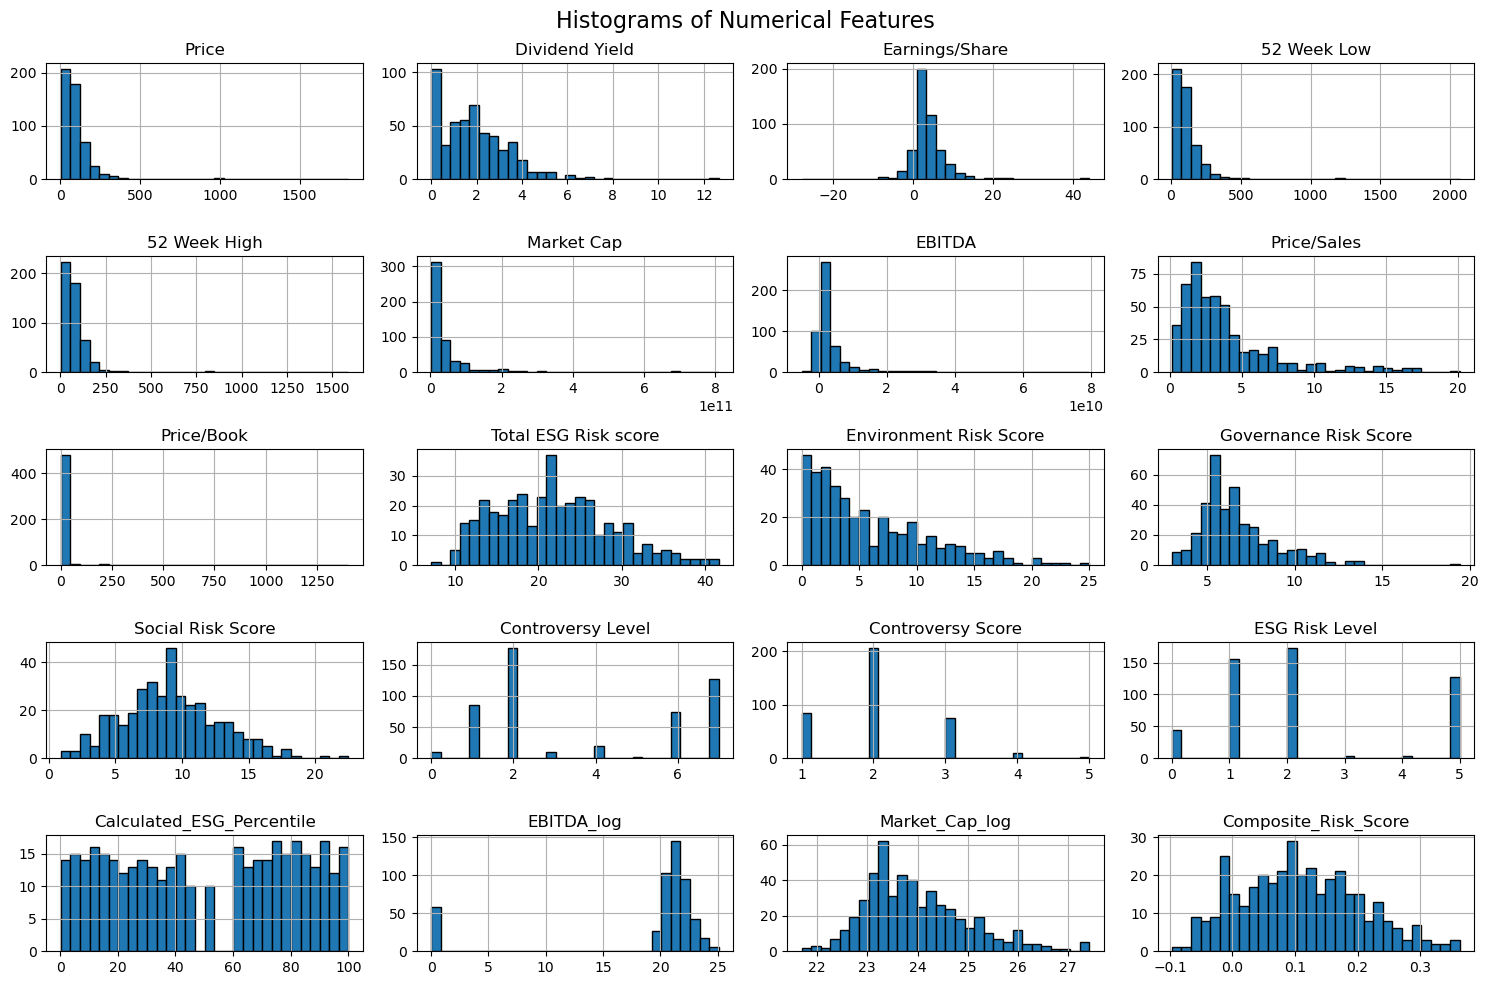

In [437]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 
merged_df.select_dtypes(include='number').hist(bins=30, figsize=(15, 10), edgecolor='black')
plt.suptitle('Histograms of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()


# Normalize the dataset for better model creation

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Select features
features = [
    'Total ESG Risk score', 'Price', 'Dividend Yield', 'Earnings/Share',
    '52 Week Low', '52 Week High', 'Market_Cap_log', 'EBITDA_log',
    'Price/Sales', 'Price/Book'
]

data = merged_df[features].copy()

# Normalize all to 0–1
scaler = MinMaxScaler()
normalized = pd.DataFrame(scaler.fit_transform(data), columns=features)


# Here assigning the weights to each of the needed features 

In [ ]:
weights = {
    'Total ESG Risk score': 0.5,
    'Price': 0.05,
    'Dividend Yield': -0.05,
    'Earnings/Share': -0.1,
    '52 Week Low': 0.05,
    '52 Week High': 0.05,
    'Market_Cap_log': -0.05,
    'EBITDA_log': -0.05,
    'Price/Sales': 0.025,
    'Price/Book': 0.025
}

In [ ]:
# Multiply each normalized feature by its weight
normalized['Weighted_Score'] = sum(normalized[col] * weight for col, weight in weights.items())

# Add Composite Risk Score back to merged_df
merged_df['Composite_Risk_Score'] = normalized['Weighted_Score']

In [ ]:
def classify_risk(score):
    if score <= merged_df['Composite_Risk_Score'].quantile(0.33):
        return 'Low Risk'
    elif score <= merged_df['Composite_Risk_Score'].quantile(0.66):
        return 'Medium Risk'
    else:
        return 'High Risk'

# Apply the classification function
merged_df['Risk_Category'] = merged_df['Composite_Risk_Score'].apply(classify_risk)



In [399]:
from sklearn.model_selection import train_test_split

# Features (X) — exclude ESG score and target
X = merged_df[[
    'Price', 'Dividend Yield', 'Earnings/Share', '52 Week Low',
    '52 Week High', 'Market_Cap_log', 'EBITDA_log',
    'Price/Sales', 'Price/Book'
]]

# Target (y)
y = merged_df['Risk_Category']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
 

In [401]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

# confusion matrix to check predicted value vs actual value and also checking the Precision, recall ,f1 score and support 

Classification Report:
               precision    recall  f1-score   support

   High Risk       0.60      0.85      0.71        55
    Low Risk       0.42      0.24      0.30        21
 Medium Risk       0.45      0.20      0.28        25

    accuracy                           0.56       101
   macro avg       0.49      0.43      0.43       101
weighted avg       0.53      0.56      0.52       101



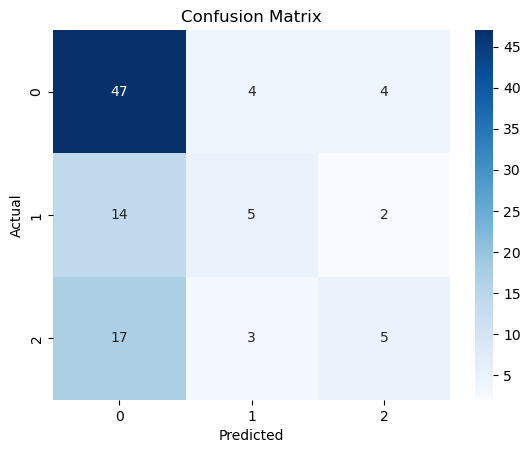

In [403]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
 

# using the model on the entire dataset 

In [415]:
merged_df['Predicted_Risk'] = model.predict(X)
merged_df[['Name_x', 'Composite_Risk_Score', 'Risk_Category', 'Predicted_Risk']].head(10)


,Name_x,Composite_Risk_Score,Risk_Category,Predicted_Risk
0,3M Company,0.320278,High Risk,High Risk
1,A.O. Smith Corp,0.175056,High Risk,High Risk
2,Abbott Laboratories,0.141005,Medium Risk,Medium Risk
3,AbbVie Inc.,0.209093,High Risk,High Risk
4,Accenture plc,-0.075863,Low Risk,Low Risk
5,Activision Blizzard,NaN,High Risk,High Risk
6,Acuity Brands Inc,NaN,High Risk,High Risk
7,Adobe Systems Inc,-0.001467,Low Risk,Low Risk
8,Advance Auto Parts,NaN,High Risk,High Risk
9,Advanced Micro Devices Inc,0.121407,Medium Risk,High Risk


# To check the count of the compnaies that fall into the 3 different categories

In [418]:
merged_df['Predicted_Risk'].value_counts()

Predicted_Risk
High Risk      286
Low Risk       112
Medium Risk    107
Name: count, dtype: int64

# Checking the entire dataset predicted values with the actual values and checking the accuracy of the model 

In [421]:
comparison = merged_df[['Risk_Category', 'Predicted_Risk']]
comparison['Match'] = comparison['Risk_Category'] == comparison['Predicted_Risk']

# See how many predictions matched the true labels
print("Correct Predictions:", comparison['Match'].sum())
print("Total Predictions:", comparison.shape[0])
print("Accuracy on full dataset:", round(comparison['Match'].mean() * 100, 2), "%")


Correct Predictions: 461
Total Predictions: 505
Accuracy on full dataset: 91.29 %


/var/folders/yp/fhmczvyn2sx778505bnnqmgr0000gn/T/ipykernel_94882/2309477716.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  comparison['Match'] = comparison['Risk_Category'] == comparison['Predicted_Risk']


# Training multiple machine learning models to compare there outputs spliting the data into train - 70 and test 30 for all the models 

In [431]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


models = {
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss') 
}

X = merged_df[[
    'Total ESG Risk score', 'Price', 'Dividend Yield', 'Earnings/Share',
    '52 Week Low', '52 Week High', 'Market_Cap_log', 'EBITDA_log',
    'Price/Sales', 'Price/Book'
]]
y = merged_df['Risk_Category']

# Encode target if it's categorical
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)

# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")


Decision Tree Accuracy: 0.9342
Random Forest Accuracy: 0.9211
XGBoost Accuracy: 0.9605


/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [17:07:50] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


# comparing models on the accuracy 

/var/folders/yp/fhmczvyn2sx778505bnnqmgr0000gn/T/ipykernel_94882/660358818.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x=model_names, y=accuracy_scores, palette='viridis')


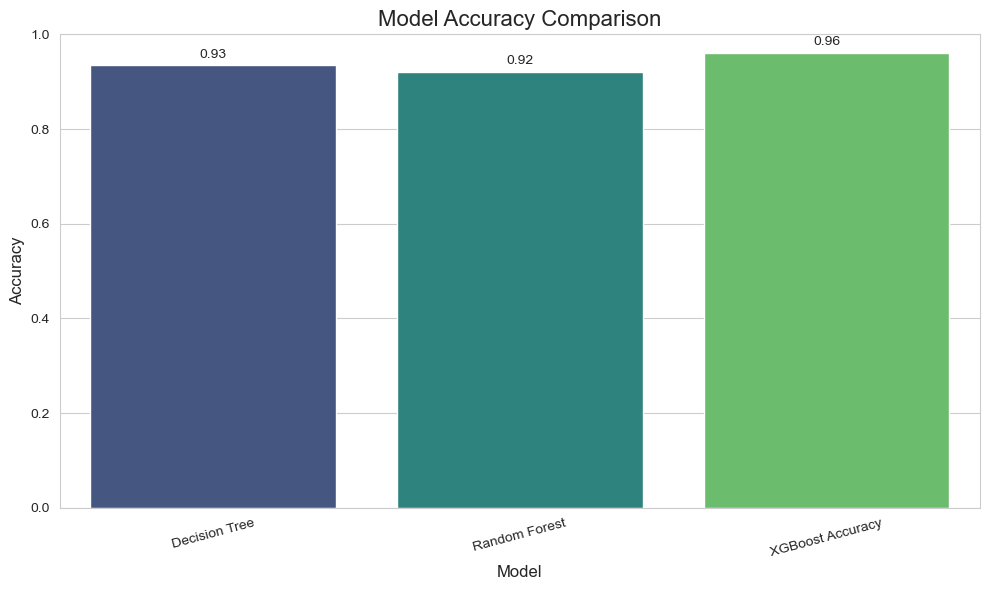

In [450]:
import matplotlib.pyplot as plt
import seaborn as sns

model_names = ['Decision Tree', 'Random Forest', 'XGBoost Accuracy']
accuracy_scores = [0.9342, 0.9211, 0.9605]  

# Plot settings
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
bar_plot = sns.barplot(x=model_names, y=accuracy_scores, palette='viridis')
bar_plot.set_ylim(0, 1)
bar_plot.set_title('Model Accuracy Comparison', fontsize=16)
bar_plot.set_ylabel('Accuracy', fontsize=12)
bar_plot.set_xlabel('Model', fontsize=12)

# Annotate accuracy values on top of bars
for i, acc in enumerate(accuracy_scores):
    plt.text(i, acc + 0.01, f"{acc:.2f}", ha='center', va='bottom', fontsize=10)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
